In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from core.rings_calc import k_symmetric, expected_dissipation_ring, compute_asymmetric_case_from_sigma

# Symmetry breaking in ring networks driven by renewable generation time series.

We consider a network belonging to the ring class with $N=3$, where every node corresponds to a geographical region. Regions $i=2,4,6$ consume power such that the injection can be written as $S_i = -\mu$. Region $i=1$ features wind turbines and region $i=3$ features solar photovoltaic plants, such that power generation at a time $t$ can be written as
\begin{align*}
    S_1(t) &= (1-\zeta) \mu + \zeta \mu Z_1(t), \\
    S_3(t) &= (1-\zeta) \mu + \zeta \mu Z_3(t),
\end{align*}
where $Z_1$ and $Z_3$ denote the normalized capacity factors of a wind turbine or solar PV plant and the parameter $\zeta \in [0,1]$ measures the share of fluctuating renewable power generation.

The capacity factor is defined as the ratio of the actual power generation at time $t$ divided by the maximum generation. Here, we rescale the capacity factor by a constant number such that $\braket{Z_1} = 1 =\braket{Z_3}$.

Finally, we assume that region $5$ hosts storage infrastructures that provide or consume the power $S_5(t) = 3\mu - S_1(t) - S_3(t)$.

In [ ]:
def load_capacity_factors(solar_file, wind_file):
    """
    Load and normalize renewable generation time series.
    Reads solar and wind power generation data from CSV files and rescales
    each time series to unit mean, yielding normalized capacity factors.
    """
    solar = pd.read_csv(solar_file)["electricity"].values
    wind  = pd.read_csv(wind_file)["electricity"].values

    solar = solar / np.mean(solar)
    wind  = wind  / np.mean(wind)

    return solar, wind

def compute_renewable_second_moments(solar, wind):
    """
    Compute second-moment matrices for renewable-driven injections.

    Constructs the empirical second moments of the stochastic injections
    in a six-node ring network with wind (node 1), solar (node 3), and a
    balancing source (node 5). The total covariance is decomposed into
    contributions from fluctuating and deterministic components.
    """
    
    T = len(solar)

    # Fluctuating source terms: node 1 = wind, node 3 = solar, node 5 = balancing source
    X1 = [wind, -np.ones(T), solar, -np.ones(T), 3 - wind - solar, -np.ones(T)]

    # Deterministic mean injection pattern
    X2 = [np.ones(T), -np.ones(T), np.ones(T), -np.ones(T), np.ones(T), -np.ones(T)]

    smm11 = np.zeros((6, 6))
    smm12 = np.zeros((6, 6))
    smm22 = np.zeros((6, 6))

    for i in range(6):
        for j in range(6):
            smm11[i, j] = np.mean(X1[i] * X1[j])
            smm12[i, j] = np.mean(X1[i] * X2[j]) + np.mean(X2[i] * X1[j])
            smm22[i, j] = np.mean(X2[i] * X2[j])

    return smm11, smm12, smm22

def symmetric_network_dissipation(N, gamma, Sigma, kappa=1.0):
    """ Compute the dissipation and capacities for the symmetric network configuration."""
    k_sym = k_symmetric(N, gamma, kappa=kappa)
    D_sym = expected_dissipation_ring(N, k_sym, Sigma)
    
    return D_sym, k_sym

We now compute the optimal network structure for a renewable-driven ring network.

We consider the six-node ring (N = 3) with stochastic injections derived from wind and solar time series. The second-moment matrix Sigma is constructed as a convex combination of fluctuating and deterministic components, controlled by the parameter zeta (share of renewable fluctuations).

For each $(\gamma, \zeta)$, we compare:
    - the symmetric closed-ring solution
    - all strongly symmetry-broken open-ring configurations (via cyclic shifts)

In [3]:
N = 3

gamma_values = np.linspace(0.3, 1.0, 400)
zeta_values = np.linspace(0.0, 1.0, 400)

capacity_values = np.zeros((len(zeta_values), len(gamma_values)))

solar_file = "energy_data/ninja_pv_50.9221_6.3611_corrected.csv"
wind_file = "energy_data/ninja_wind_50.9221_6.3611_corrected.csv"

solar, wind = load_capacity_factors(solar_file, wind_file)
smm11, smm12, smm22 = compute_renewable_second_moments(solar, wind)

total_points = len(zeta_values) * len(gamma_values)
point_counter = 0

for i, zeta in enumerate(zeta_values):
    Sigma = (zeta**2 * smm11 + (1 - zeta)**2 * smm22  + zeta * (1 - zeta) * smm12)

    for j, gamma in enumerate(gamma_values):
        point_counter += 1
        print(f"[{point_counter}/{total_points}] ({i}, {j})", end="\r", flush=True)

        # Symmetric closed ring
        D_sym, k_sym = symmetric_network_dissipation(N, gamma, Sigma)
        best_D = D_sym
        best_k = k_sym

        # Test all shifted strongly broken open-ring states
        for shift in range(2 * N):
            Sigma_shift = np.roll(Sigma, shift, axis=0)
            Sigma_shift = np.roll(Sigma_shift, shift, axis=1)

            D_brk, k_brk = compute_asymmetric_case_from_sigma(N, gamma, Sigma_shift, kappa=1.0, broken_edge=-1)

            if D_brk < best_D:
                best_D = D_brk
                best_k = k_brk

        capacity_values[i, j] = np.min(best_k)

print()

[160000/160000] (399, 399)


# Figure 7

The minimum edge capacity $min_e(k_e^*)$ is an order parameter, yielding a phase diagram over $(\gamma, \zeta)$. When this value is zero, an edge is missing from the network.

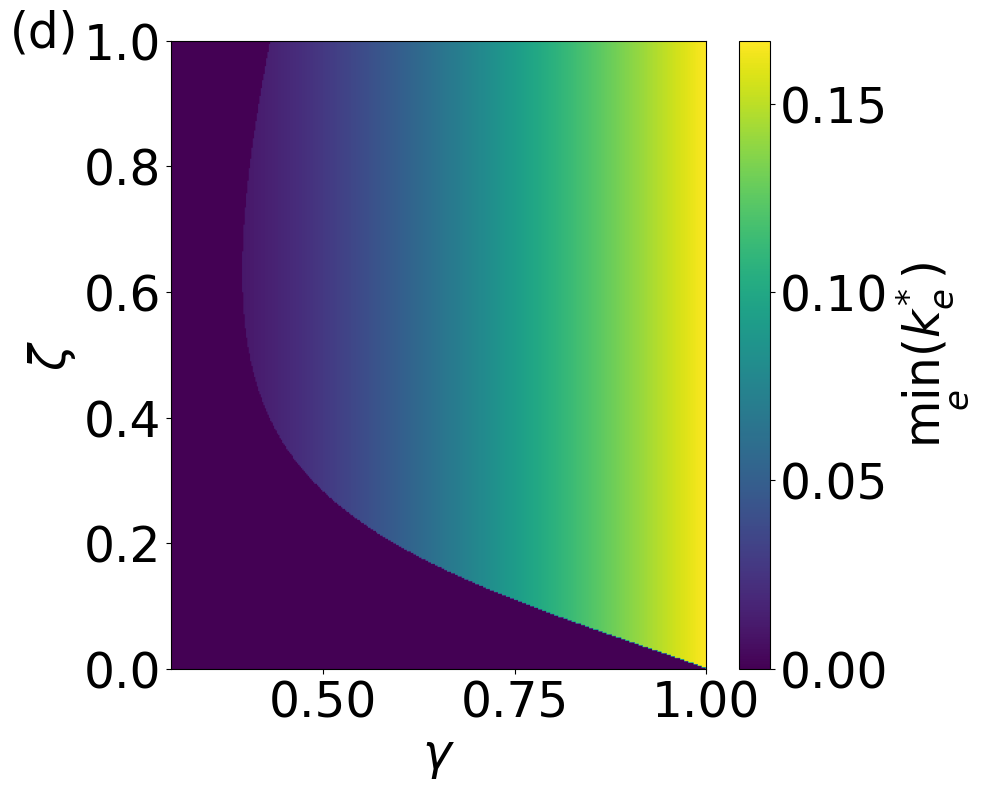

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(capacity_values, origin="lower", aspect="auto", extent=[gamma_values[0], gamma_values[-1], zeta_values[0], zeta_values[-1]],
           cmap="viridis")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$\min_e(k_e^*)$",fontsize=35)
cbar.ax.tick_params(labelsize=35)  

ax.set_xlabel(r"$\gamma$",fontsize=35)
ax.set_ylabel(r"$\zeta$",fontsize=35)
ax.tick_params(axis='both', labelsize=35) 

ax.text(-0.3, 1.05, "(d)", transform=ax.transAxes, fontsize=35, va="top")

plt.tight_layout()
fig.savefig("Renewables_d.pdf", bbox_inches="tight")
plt.show()

Plot time series of stochastic power injections in the renewable network.

The plot displays the injections at the three generator nodes corresponding to wind ($S_1$), solar ($S_3$), and the balancing unit ($S_5$), constructed from normalized capacity factors and scaled by the fluctuation parameter zeta.

In [ ]:
def plot_renewables_sources_timeseries(solar_file, wind_file, zeta=1.0, mu=1.0, savepath=None):
    solar, wind = load_capacity_factors(solar_file, wind_file)

    # Capacity factors
    Z1 = wind
    Z3 = solar
    Z5 = 3.0 - wind - solar

    # Injections
    S1 = (1 - zeta) * mu + zeta * mu * Z1
    S3 = (1 - zeta) * mu + zeta * mu * Z3
    S5 = 3 * mu - S1 - S3

    t = np.arange(len(S1))

    fig, axs = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

    axs[0].plot(t, S1, lw=1.5, color="#1f77b4")
    axs[0].set_ylabel(r"$S_1(t)$", fontsize=25)
    axs[0].tick_params(axis="y", labelsize=20)

    axs[1].plot(t, S3, lw=1.5, color="#ffb100")
    axs[1].set_ylabel(r"$S_3(t)$", fontsize=25)
    axs[1].tick_params(axis="y", labelsize=20)

    axs[2].plot(t, S5, lw=1.5, color="#d62787")
    axs[2].set_ylabel(r"$S_5(t)$", labelpad = -12, fontsize=25)
    axs[2].set_xlabel(r"$t$ [hours]", fontsize=25)
    axs[2].tick_params(axis="both", labelsize=20)

    axs[0].text(-0.18, 1.05, "(a)", transform=axs[0].transAxes, fontsize=25, va="top")
    axs[1].text(-0.18, 1.05, "(b)", transform=axs[1].transAxes, fontsize=25, va="top")
    axs[2].text(-0.18, 1.05, "(c)", transform=axs[2].transAxes, fontsize=25, va="top")

    plt.tight_layout(rect=[0.08, 0, 1, 1])

    if savepath is not None:
        fig.savefig(savepath, format="pdf", bbox_inches="tight")

    plt.show()
    return fig, axs

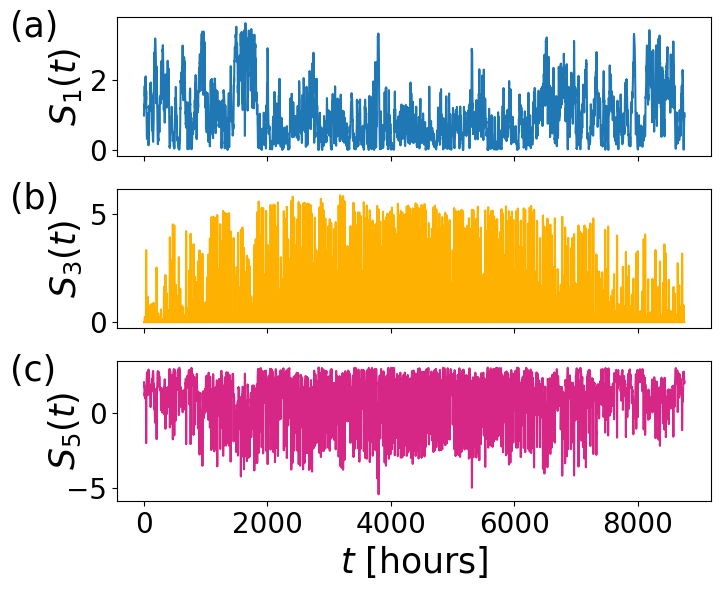

In [27]:
fig, axs = plot_renewables_sources_timeseries(solar_file, wind_file, zeta=1.0, mu=1.0, savepath="Renewables_abc.pdf")